In [2]:
%pip install stanza


[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import stanza
from collections import Counter
from itertools import islice


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Load datasets
fake_df = pd.read_csv("../data/Fake.csv")
true_df = pd.read_csv("../data/True.csv")

# Check the first few rows
print("Fake news dataset:")
print(fake_df.head())

print("\nTrue news dataset:")
print(true_df.head())

print(true_df.shape, fake_df.shape)


Fake news dataset:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  

True news dataset:
                                               title  \
0  As U.S. budget fight looms, Republicans fl

In [5]:
fake_df.info()
true_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [6]:
true_df.nunique()
fake_df.nunique()

title      17903
text       17455
subject        6
date        1681
dtype: int64

In [7]:
true_df.describe(include='all')
fake_df.describe(include='all')

,title,text,subject,date
count,23481,23481,23481,23481
unique,17903,17455,6,1681
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"May 10, 2017"
freq,6,626,9050,46


In [8]:
true_df.isnull().sum()
fake_df.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [9]:

LANG = "en"              
stanza.download(LANG)    
nlp = stanza.Pipeline(LANG, processors="tokenize,pos,lemma", tokenize_no_ssplit=True, use_gpu=True)

def _ngrams(seq, n):
    return zip(*(islice(seq, i, None) for i in range(n)))

def tokenize_subjects(subjects, keep_upos={"NOUN","PROPN","ADJ","VERB"}, use_lemmas=True):
    """
    subjects: iterable[str]
    returns: list[list[str]] tokens per subject
    """
    tokenized = []
    for s in subjects:
        doc = nlp(s if isinstance(s, str) else str(s))
        toks = []
        for sent in doc.sentences:
            for w in sent.words:
                if w.upos == "PUNCT":
                    continue
                if keep_upos and w.upos not in keep_upos:
                    continue
                tok = (w.lemma if use_lemmas else w.text).lower()
                toks.append(tok)
        tokenized.append(toks)
    return tokenized

def analyze_subjects(df, label, top_k=20):
    subjects = df['subject'].astype(str).fillna("").tolist()
    tokens_per_subject = tokenize_subjects(subjects)

    word_counts = Counter()
    for toks in tokens_per_subject:
        word_counts.update(toks)

    bigrams = Counter()
    trigrams = Counter()
    for toks in tokens_per_subject:
        bigrams.update(_ngrams(toks, 2))
        trigrams.update(_ngrams(toks, 3))
    bigrams = Counter({" ".join(k): v for k, v in bigrams.items()})
    trigrams = Counter({" ".join(k): v for k, v in trigrams.items()})

    lengths = [len(toks) for toks in tokens_per_subject]
    stats = {
        "dataset": label,
        "rows": len(df),
        "unique_subject_strings": df['subject'].nunique(),
        "mean_tokens_per_subject": float(np.mean(lengths)) if lengths else 0.0,
        "median_tokens_per_subject": float(np.median(lengths)) if lengths else 0.0,
        "type_token_ratio": (len(word_counts) / max(sum(lengths), 1)) if lengths else 0.0,
        "top_subject_strings": df['subject'].value_counts().head(top_k),
        "top_words": word_counts.most_common(top_k),
        "top_bigrams": bigrams.most_common(top_k),
        "top_trigrams": trigrams.most_common(top_k),
        "word_counts": word_counts,
        "bigram_counts": bigrams,
        "trigram_counts": trigrams,
    }
    return stats

true_stats = analyze_subjects(true_df, "TRUE")
fake_stats = analyze_subjects(fake_df, "FAKE")

def print_stats(stats):
    print(f"\n=== {stats['dataset']} dataset ===")
    print(f"Rows: {stats['rows']}")
    print(f"Unique subject strings: {stats['unique_subject_strings']}")
    print(f"Mean tokens/subject: {stats['mean_tokens_per_subject']:.2f}")
    print(f"Median tokens/subject: {stats['median_tokens_per_subject']:.0f}")
    print(f"Type/Token ratio: {stats['type_token_ratio']:.3f}")

    print("\nTop subject strings:")
    for s, c in stats["top_subject_strings"].items():
        print(f"  {c:>6}  {s}")

    print("\nTop words (lemmas):")
    for w, c in stats["top_words"]:
        print(f"  {c:>6}  {w}")

    print("\nTop bigrams:")
    for g, c in stats["top_bigrams"]:
        print(f"  {c:>6}  {g}")

    print("\nTop trigrams:")
    for g, c in stats["top_trigrams"]:
        print(f"  {c:>6}  {g}")

print_stats(true_stats)
print_stats(fake_stats)

def log_odds_ratio(counts_A, counts_B, alpha=0.01, top_k=20):
    vocab = set(counts_A) | set(counts_B)
    A = np.array([counts_A.get(t, 0) + alpha for t in vocab], dtype=float)
    B = np.array([counts_B.get(t, 0) + alpha for t in vocab], dtype=float)
    A_tot, B_tot = A.sum(), B.sum()
    logit_A = np.log(A / (A_tot - A))
    logit_B = np.log(B / (B_tot - B))
    delta = logit_A - logit_B
    var = 1/A + 1/B
    z = delta / np.sqrt(var)
    terms = list(vocab)
    top_A = sorted(zip(terms, z), key=lambda x: -x[1])[:top_k]
    top_B = sorted(zip(terms, z), key=lambda x: x[1])[:top_k]
    return top_A, top_B

print("\n=== Distinctive words (TRUE vs FAKE) ===")
top_true, top_fake = log_odds_ratio(true_stats["word_counts"], fake_stats["word_counts"])
print("\nMore distinctive for TRUE:")
for t, z in top_true: print(f"  {z:>7.2f}  {t}")
print("\nMore distinctive for FAKE:")
for t, z in top_fake: print(f"  {z:>7.2f}  {t}")

2025-09-15 08:54:41 INFO: Downloaded file to /Users/alexandrud.soroiu/stanza_resources/resources.json
2025-09-15 08:54:41 INFO: Downloading default packages for language: en (English) ...
2025-09-15 08:54:42 INFO: File exists: /Users/alexandrud.soroiu/stanza_resources/en/default.zip
2025-09-15 08:54:44 INFO: Finished downloading models and saved to /Users/alexandrud.soroiu/stanza_resources
2025-09-15 08:54:44 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES
2025-09-15 08:54:44 INFO: Downloaded file to /Users/alexandrud.soroiu/stanza_resources/resources.json
2025-09-15 08:54:44 WARNING: Language en package default expects mwt, which has been added
2025-09-15 08:54:44 INFO: Loading these models for language: en (English):
| Processor | Package           |
---------------------------------
| tokenize  | combined          |
| mwt       | combined 


=== TRUE dataset ===
Rows: 21417
Unique subject strings: 2
Mean tokens/subject: 1.00
Median tokens/subject: 1
Type/Token ratio: 0.000

Top subject strings:
   11272  politicsNews
   10145  worldnews

Top words (lemmas):
   11272  politicsnew
   10145  worldnew

Top bigrams:

Top trigrams:

=== FAKE dataset ===
Rows: 23481
Unique subject strings: 6
Mean tokens/subject: 1.29
Median tokens/subject: 1
Type/Token ratio: 0.000

Top subject strings:
    9050  News
    6841  politics
    4459  left-news
    1570  Government News
     783  US_News
     778  Middle-east

Top words (lemmas):
   15079  news
    6841  politics
    4459  left
    1570  government
     783  us_news
     778  middle
     778  east

Top bigrams:
    4459  left news
    1570  government news
     778  middle east

Top trigrams:

=== Distinctive words (TRUE vs FAKE) ===

More distinctive for TRUE:
     1.50  politicsnew
     1.48  worldnew
    -1.09  middle
    -1.09  east
    -1.09  us_news
    -1.17  government
    -1

In [12]:
%pip install scipy


  Obtaining dependency information for scipy from https://files.pythonhosted.org/packages/91/4d/281fddc3d80fd738ba86fd3aed9202331180b01e2c78eaae0642f22f7e83/scipy-1.16.2-cp312-cp312-macosx_14_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.2 MB/s eta 0:00:00-:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 22.5 MB/s eta 0:00:0000:0100:01

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [13]:
import re
from math import log

# --- 1) normalize subjects ---
def split_camel(s: str) -> str:
    # politicsNews -> politics News
    return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', s)

def normalize_subject(s: str) -> str:
    if not isinstance(s, str):
        s = str(s) if s is not None else ""
    s = s.strip()
    s = split_camel(s)
    s = s.replace('_', ' ').replace('-', ' ')
    s = re.sub(r'\s+', ' ', s)
    return s.lower()

true_subj = true_df['subject'].astype(str).map(normalize_subject)
fake_subj = fake_df['subject'].astype(str).map(normalize_subject)

# --- 2) frequency table (counts + percentages) ---
true_counts = true_subj.value_counts().sort_index()
fake_counts = fake_subj.value_counts().sort_index()
all_subjects = sorted(set(true_counts.index) | set(fake_counts.index))

freq = pd.DataFrame({
    'subject': all_subjects,
    'true_count': [int(true_counts.get(s, 0)) for s in all_subjects],
    'fake_count': [int(fake_counts.get(s, 0)) for s in all_subjects],
})
freq['true_pct'] = freq['true_count'] / max(len(true_subj), 1)
freq['fake_pct'] = freq['fake_count'] / max(len(fake_subj), 1)
freq = freq.sort_values(['true_count','fake_count'], ascending=False).reset_index(drop=True)

print("\n=== Subject distribution (counts & percentages) ===")
print(freq.to_string(index=False))

# --- 3) chi-square test of independence ---
from scipy.stats import chi2_contingency

contingency = np.vstack([freq['true_count'].values, freq['fake_count'].values])
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square: {chi2:.2f}, dof={dof}, p-value={p:.3e}")
if p < 0.05:
    print("=> Subject distribution differs significantly between TRUE and FAKE.")
else:
    print("=> No significant difference detected (at α=0.05).")

# --- 4) log-odds per subject (overrepresentation) ---
def log_odds(counts_A: pd.Series, counts_B: pd.Series, alpha=0.5):
    # Additive smoothing
    A = counts_A.reindex(all_subjects, fill_value=0).astype(float) + alpha
    B = counts_B.reindex(all_subjects, fill_value=0).astype(float) + alpha
    A_tot, B_tot = A.sum(), B.sum()
    # log odds for class A vs B
    lo = np.log((A / (A_tot - A)) / (B / (B_tot - B)))
    return pd.Series(lo, index=all_subjects).sort_values(ascending=False)

lo_true_vs_fake = log_odds(true_counts, fake_counts, alpha=0.5)
lo_fake_vs_true = -lo_true_vs_fake

print("\n=== Subjects most overrepresented in TRUE (log-odds) ===")
print(lo_true_vs_fake.head(10).to_string())

print("\n=== Subjects most overrepresented in FAKE (log-odds) ===")
print(lo_fake_vs_true.head(10).to_string())

# --- 5) token/phrase frequency over normalized subject text ---
def subject_token_counts(series: pd.Series, n=1):
    tokens = []
    for s in series:
        toks = s.split()
        if n == 1:
            tokens.extend(toks)
        else:
            tokens.extend([' '.join(toks[i:i+n]) for i in range(len(toks)-n+1)])
    return Counter(tokens)

true_word = subject_token_counts(true_subj, n=1)
fake_word = subject_token_counts(fake_subj, n=1)
true_big = subject_token_counts(true_subj, n=2)
fake_big = subject_token_counts(fake_subj, n=2)

print("\nTop subject words – TRUE:", true_word.most_common(10))
print("Top subject words – FAKE:", fake_word.most_common(10))
print("Top subject bigrams – TRUE:", true_big.most_common(10))
print("Top subject bigrams – FAKE:", fake_big.most_common(10))



=== Subject distribution (counts & percentages) ===
        subject  true_count  fake_count  true_pct  fake_pct
  politics news       11272           0  0.526311  0.000000
      worldnews       10145           0  0.473689  0.000000
           news           0        9050  0.000000  0.385418
       politics           0        6841  0.000000  0.291342
      left news           0        4459  0.000000  0.189898
government news           0        1570  0.000000  0.066863
        us news           0         783  0.000000  0.033346
    middle east           0         778  0.000000  0.033133

Chi-square: 44898.00, dof=7, p-value=0.000e+00
=> Subject distribution differs significantly between TRUE and FAKE.

=== Subjects most overrepresented in TRUE (log-odds) ===
politics news      10.862283
worldnews          10.651641
middle east        -7.292213
us news            -7.298836
government news    -8.029496
left news          -9.214507
politics           -9.776238
news              -10.198450


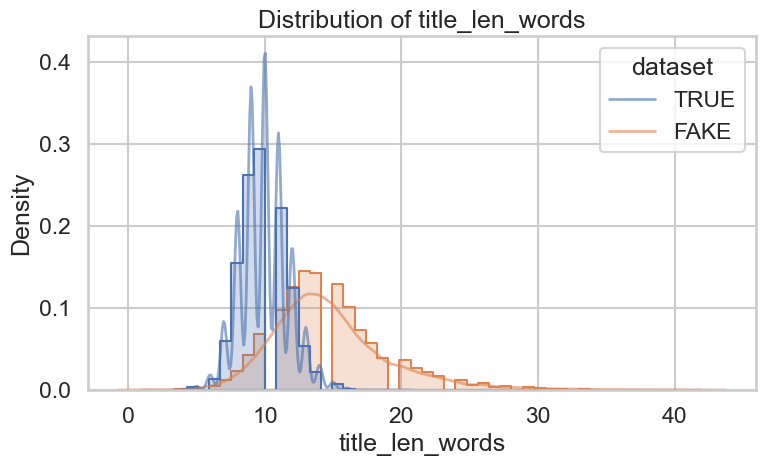

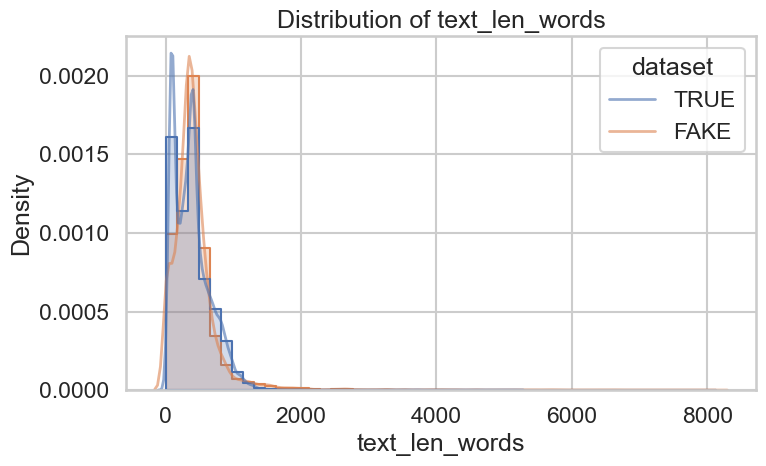

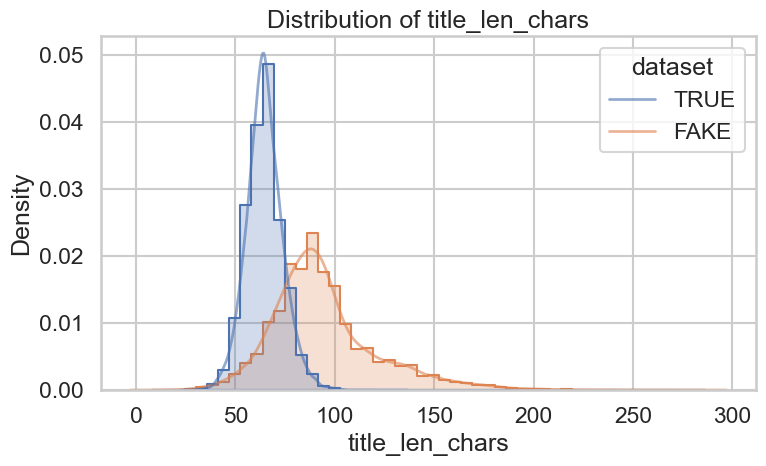

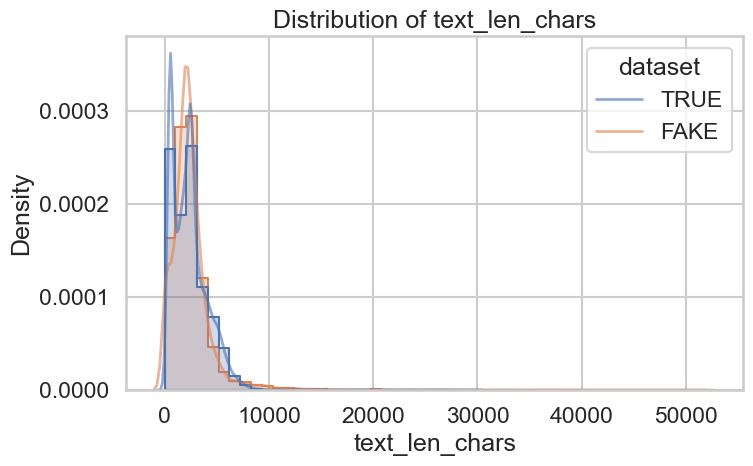

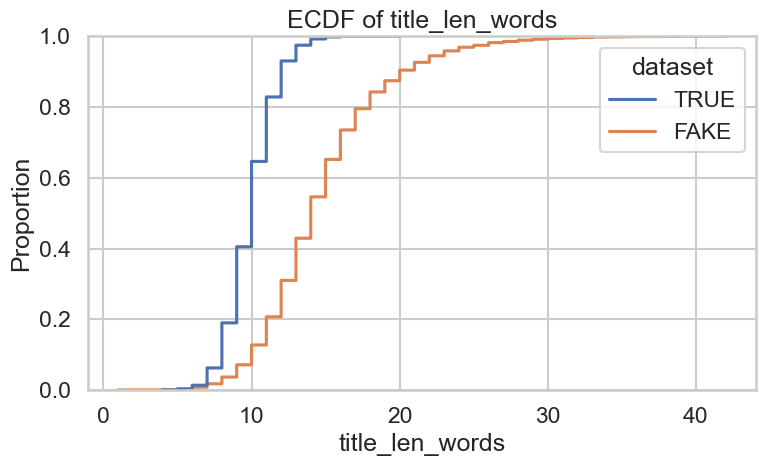

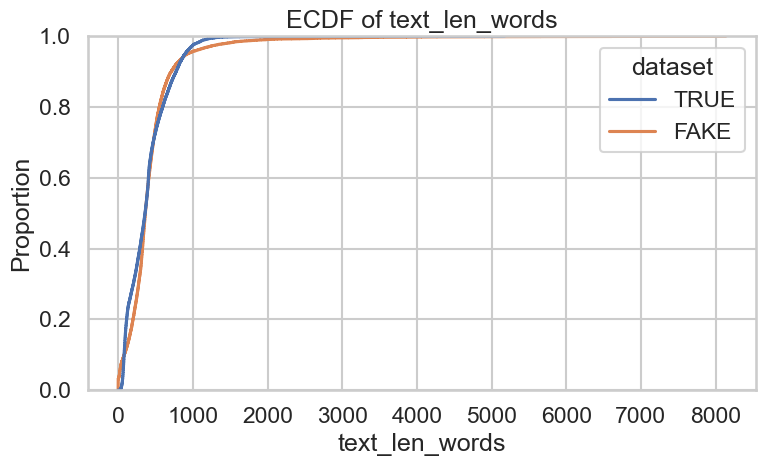

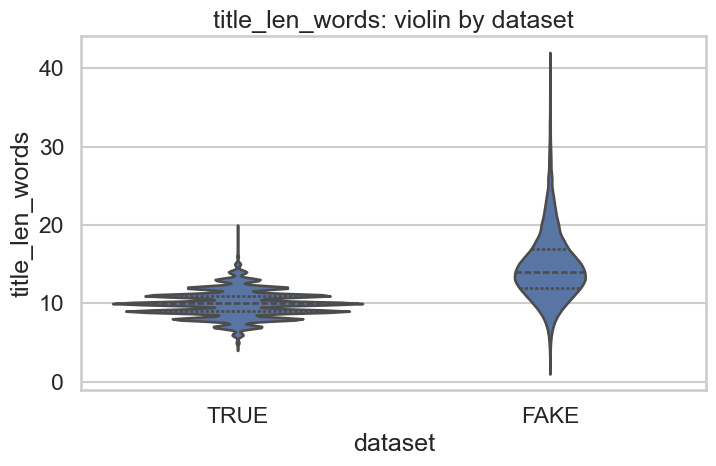

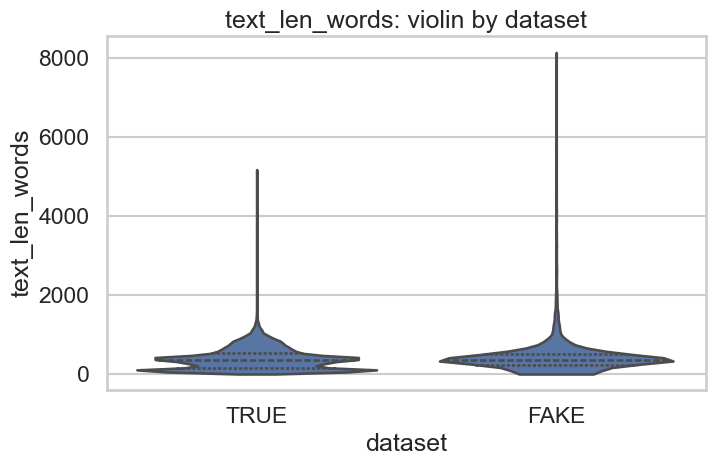

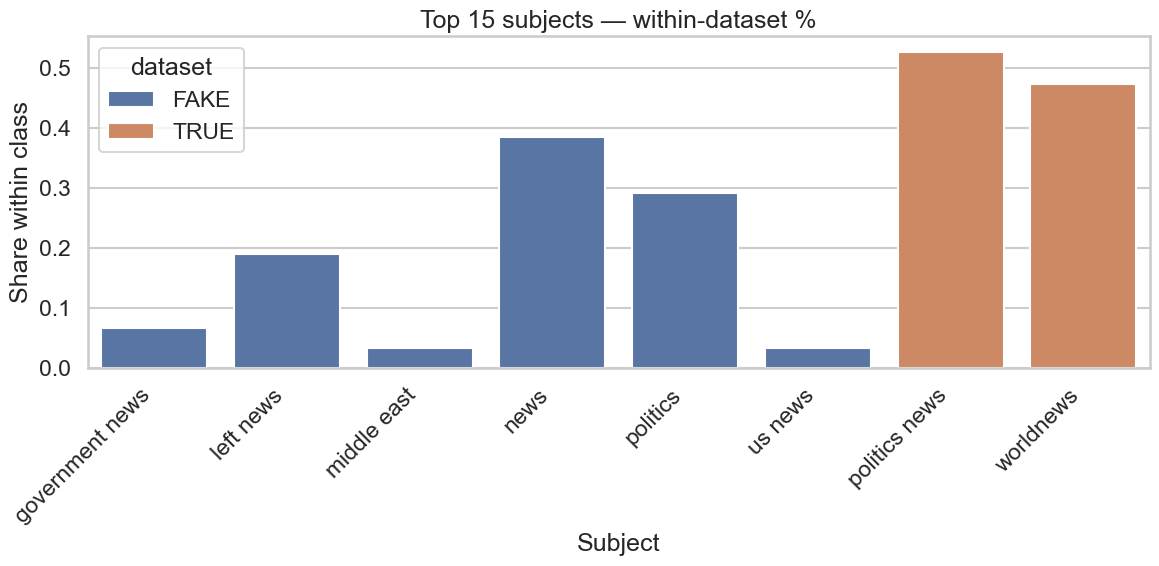

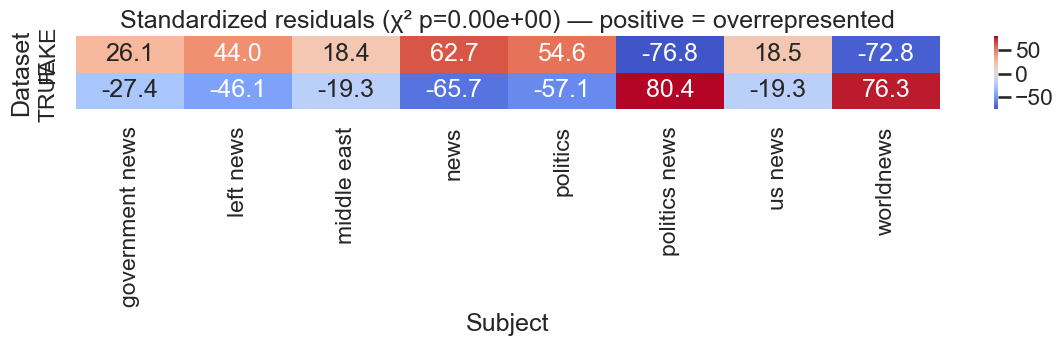

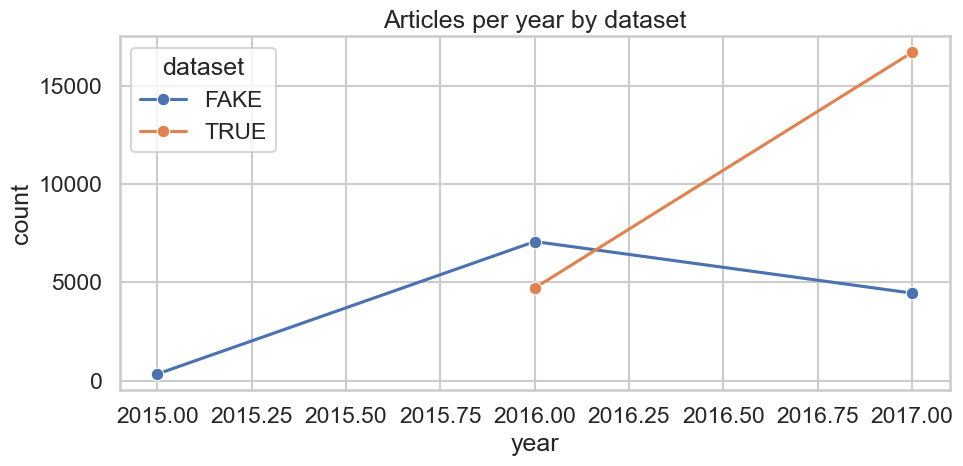

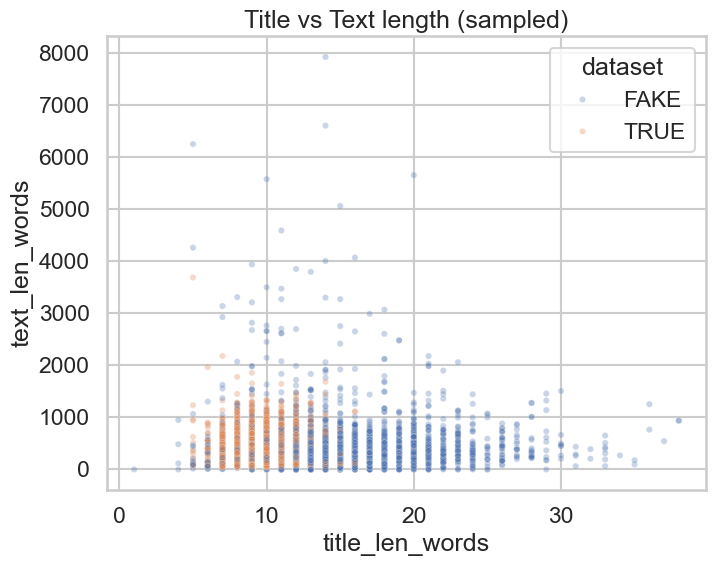

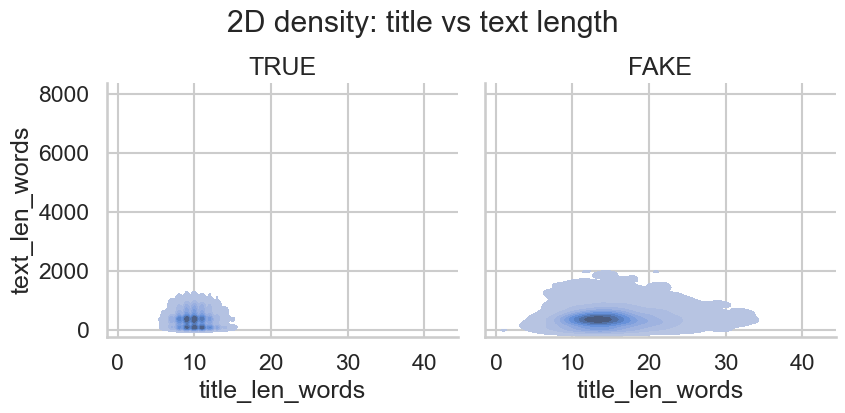

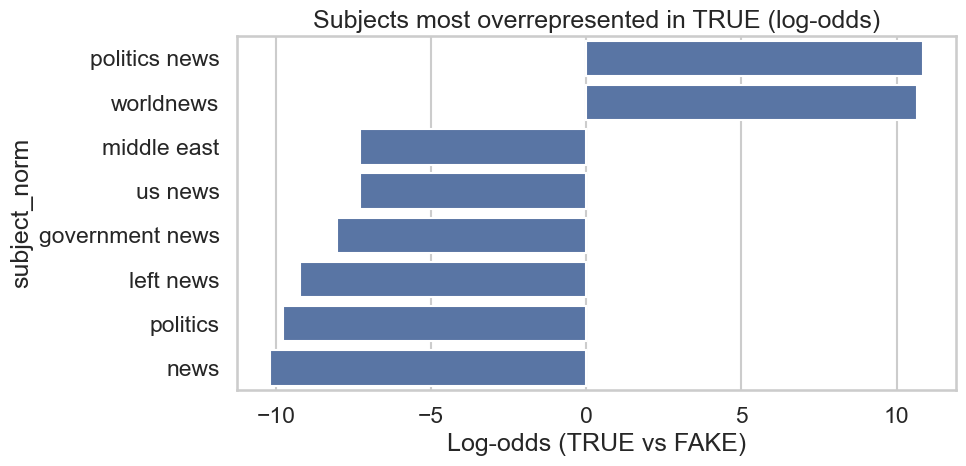

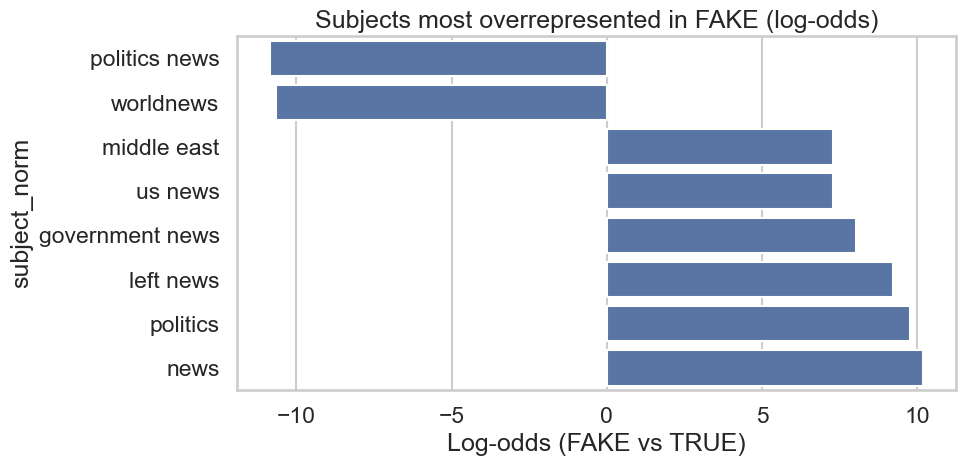

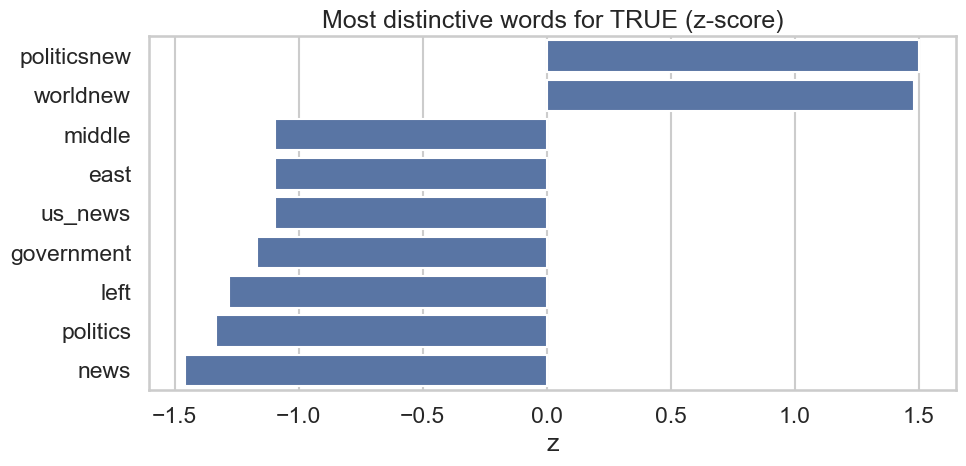

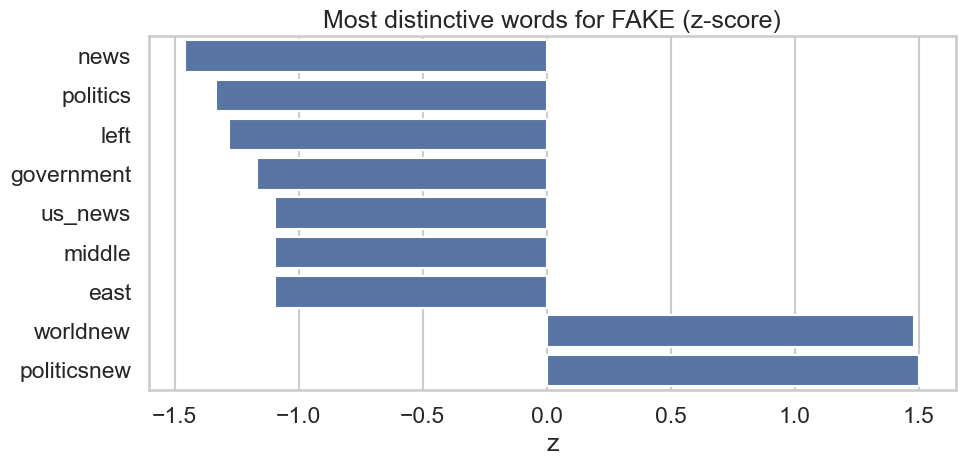

In [14]:
# --- Seaborn comparisons: TRUE vs FAKE ---
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

sns.set(style="whitegrid", context="talk")

# ---------- Prep combined frame with derived features ----------
def normalize_subject(s: str) -> str:
    import re
    def split_camel(x: str) -> str:
        return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', x)
    if not isinstance(s, str):
        s = str(s) if s is not None else ""
    s = s.strip()
    s = split_camel(s)
    s = s.replace('_', ' ').replace('-', ' ')
    s = re.sub(r'\s+', ' ', s)
    return s.lower()

def add_features(df, label):
    out = df.copy()
    out["dataset"] = label
    out["title_len_words"] = out["title"].fillna("").str.split().str.len()
    out["title_len_chars"] = out["title"].fillna("").str.len()
    out["text_len_words"]  = out["text"].fillna("").str.split().str.len()
    out["text_len_chars"]  = out["text"].fillna("").str.len()
    out["subject_norm"]    = out["subject"].astype(str).map(normalize_subject)
    out["date_parsed"]     = pd.to_datetime(out["date"].astype(str).str.strip(), errors="coerce")
    out["year"]            = out["date_parsed"].dt.year
    return out

true_ = add_features(true_df, "TRUE")
fake_ = add_features(fake_df, "FAKE")
df_all = pd.concat([true_, fake_], ignore_index=True)

# ---------- 1) Length distributions (overlayed) ----------
num_cols = ["title_len_words", "text_len_words", "title_len_chars", "text_len_chars"]
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=df_all, x=col, hue="dataset", bins=50, stat="density", common_norm=False, element="step")
    sns.kdeplot(data=df_all, x=col, hue="dataset", common_norm=False, linewidth=2, alpha=0.6)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

# ECDF (very revealing for skewed lengths)
for col in ["title_len_words", "text_len_words"]:
    plt.figure(figsize=(8, 5))
    sns.ecdfplot(data=df_all, x=col, hue="dataset")
    plt.title(f"ECDF of {col}")
    plt.tight_layout()
    plt.show()

# ---------- 2) Box/violin plots by label (robust view of medians/outliers) ----------
for col in ["title_len_words", "text_len_words"]:
    plt.figure(figsize=(7.5, 5))
    sns.violinplot(data=df_all, x="dataset", y=col, cut=0, inner="quartile")
    plt.title(f"{col}: violin by dataset")
    plt.tight_layout()
    plt.show()

# ---------- 3) Subject distribution (top N, side-by-side) ----------
TOP_N = 15
sub_counts = (df_all
              .assign(subject_norm=lambda d: d["subject_norm"].fillna("unknown"))
              .groupby(["dataset", "subject_norm"])
              .size()
              .reset_index(name="count"))

# Convert to within-dataset percentages to neutralize class size differences
sub_counts["pct"] = sub_counts.groupby("dataset")["count"].transform(lambda x: x / x.sum())

# Pick global top-N subjects by total count
top_subjects = (sub_counts.groupby("subject_norm")["count"].sum()
                .sort_values(ascending=False).head(TOP_N).index.tolist())
sub_top = sub_counts[sub_counts["subject_norm"].isin(top_subjects)]

plt.figure(figsize=(12, 6))
sns.barplot(data=sub_top, x="subject_norm", y="pct", hue="dataset")
plt.title(f"Top {TOP_N} subjects — within-dataset %")
plt.xlabel("Subject")
plt.ylabel("Share within class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ---------- 4) Chi-square residual heatmap (which subjects are over/under represented?) ----------
# Build contingency for the same top subjects
cont = (df_all.assign(subject_norm=lambda d: d["subject_norm"].fillna("unknown"))
        .query("subject_norm in @top_subjects")
        .pivot_table(index="dataset", columns="subject_norm", values="title", aggfunc="size", fill_value=0))
chi2, p, dof, expected = chi2_contingency(cont.values)
residuals = (cont - expected) / np.sqrt(expected)  # standardized residuals

plt.figure(figsize=(12, 3.8))
sns.heatmap(residuals, annot=True, fmt=".1f", center=0, cmap="coolwarm")
plt.title(f"Standardized residuals (χ² p={p:.2e}) — positive = overrepresented")
plt.xlabel("Subject")
plt.ylabel("Dataset")
plt.tight_layout()
plt.show()

# ---------- 5) Yearly volume by dataset ----------
yr = (df_all.dropna(subset=["year"])
      .groupby(["dataset", "year"])
      .size()
      .reset_index(name="count"))

plt.figure(figsize=(10, 5))
sns.lineplot(data=yr, x="year", y="count", hue="dataset", marker="o")
plt.title("Articles per year by dataset")
plt.tight_layout()
plt.show()

# ---------- 6) Joint relationship: title vs text length ----------
plt.figure(figsize=(7.5, 6))
sns.scatterplot(data=df_all.sample(min(len(df_all), 8000), random_state=0),
                x="title_len_words", y="text_len_words", hue="dataset", alpha=0.3, s=20)
plt.title("Title vs Text length (sampled)")
plt.tight_layout()
plt.show()

# Optional: density contours per class
g = sns.FacetGrid(df_all, col="dataset", height=4, aspect=1.1)
g.map_dataframe(sns.kdeplot, x="title_len_words", y="text_len_words", fill=True, thresh=0.02, levels=10)
g.set_titles("{col_name}")
g.fig.suptitle("2D density: title vs text length", y=1.05)
plt.show()

# ---------- 7) Log-odds subjects barplots (using your earlier log_odds) ----------
# (Recompute here for safety, using same alpha=0.5)
true_counts = true_["subject_norm"].value_counts()
fake_counts = fake_["subject_norm"].value_counts()
all_subjects = sorted(set(true_counts.index) | set(fake_counts.index))

def log_odds_series(counts_A, counts_B, alpha=0.5):
    A = counts_A.reindex(all_subjects, fill_value=0).astype(float) + alpha
    B = counts_B.reindex(all_subjects, fill_value=0).astype(float) + alpha
    A_tot, B_tot = A.sum(), B.sum()
    lo = np.log((A / (A_tot - A)) / (B / (B_tot - B)))
    return lo.sort_values(ascending=False)

lo_true_vs_fake = log_odds_series(true_counts, fake_counts, alpha=0.5)
lo_fake_vs_true = -lo_true_vs_fake

k = 12
plt.figure(figsize=(10, 5))
sns.barplot(x=lo_true_vs_fake.head(k).values, y=lo_true_vs_fake.head(k).index, orient="h")
plt.title("Subjects most overrepresented in TRUE (log-odds)")
plt.xlabel("Log-odds (TRUE vs FAKE)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x=lo_fake_vs_true.head(k).values, y=lo_fake_vs_true.head(k).index, orient="h")
plt.title("Subjects most overrepresented in FAKE (log-odds)")
plt.xlabel("Log-odds (FAKE vs TRUE)")
plt.tight_layout()
plt.show()

# ---------- 8) Distinctive WORDS from your z-scores (if you still have top_true/top_fake) ----------
# If you kept top_true/top_fake from your 'log_odds_ratio' (z-scores), plot them:
try:
    # top_true = [('term', z), ...]
    terms_true, z_true = zip(*top_true[:15])
    terms_fake, z_fake = zip(*top_fake[:15])

    plt.figure(figsize=(10, 5))
    sns.barplot(x=z_true, y=list(terms_true), orient="h")
    plt.title("Most distinctive words for TRUE (z-score)")
    plt.xlabel("z")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 5))
    sns.barplot(x=z_fake, y=list(terms_fake), orient="h")
    plt.title("Most distinctive words for FAKE (z-score)")
    plt.xlabel("z")
    plt.tight_layout()
    plt.show()
except Exception as e:
    print("[info] Skipping word z-score plots (top_true/top_fake not in scope):", e)

In [15]:
%pip install scikit-learn

  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/43/5d/779320063e88af9c4a7c2cf463ff11c21ac9c8bd730c4a294b0000b666c9/scikit_learn-1.7.2-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for joblib>=1.2.0 from https://files.pythonhosted.org/packages/1e/e8/685f47e0d754320684db4425a0967f7d3fa70126bffd76110b7009a0090f/joblib-1.5.2-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.1.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 18.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.4/308.4 kB 11.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.2.1 -> 25.2
[notice] To update, run: pip3.12 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Deduped size: 44685
Split sizes -> train: 31279  val: 8937  test: 4469
Label share (pos=1) -> train: 0.475  val: 0.475  test: 0.475

=== VALIDATION metrics ===
              precision    recall  f1-score   support

           0      0.995     0.997     0.996      4695
           1      0.996     0.995     0.996      4242

    accuracy                          0.996      8937
   macro avg      0.996     0.996     0.996      8937
weighted avg      0.996     0.996     0.996      8937

Confusion matrix:
 [[4680   15]
 [  23 4219]]
ROC-AUC: 1.000


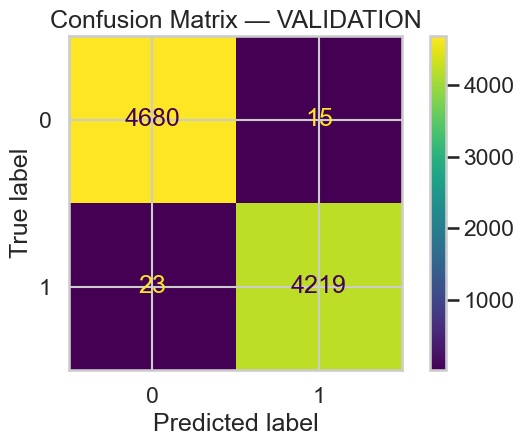


=== TEST metrics ===
              precision    recall  f1-score   support

           0      0.996     0.998     0.997      2348
           1      0.998     0.995     0.997      2121

    accuracy                          0.997      4469
   macro avg      0.997     0.997     0.997      4469
weighted avg      0.997     0.997     0.997      4469

Confusion matrix:
 [[2344    4]
 [  10 2111]]
ROC-AUC: 1.000


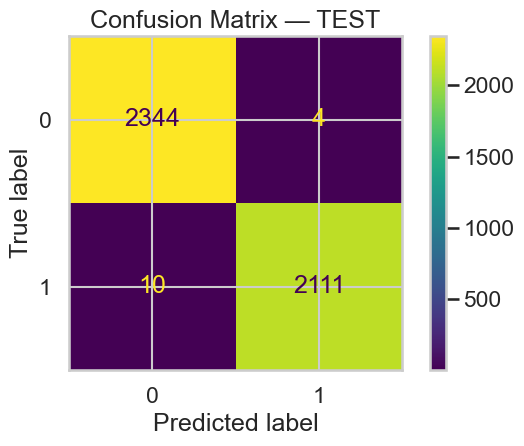


CV accuracy on train+val: mean=0.997 ± 0.001

Top features for TRUE (class 1):
   7.918  reuters
   5.648  said
   3.155  washington reuters
   2.778  on
   2.080  said on
   2.035  reuters the
   1.978  factbox
   1.836  on wednesday
   1.780  washington
   1.714  says
   1.662  in
   1.645  on thursday
   1.637  on tuesday
   1.624  president donald
   1.594  reuters president
   1.518  republican
   1.499  on friday
   1.492  said in
   1.379  on monday
   1.272  wednesday

Top features for FAKE (class 0):
  -4.269  video
  -3.370  via
  -2.731  breaking
  -2.019  read more
  -1.928  this
  -1.890  us
  -1.745  image
  -1.734  read
  -1.726  hillary
  -1.659  featured image
  -1.639  featured
  -1.632  the us
  -1.576  mr
  -1.544  is
  -1.505  image via
  -1.483  that
  -1.473  the
  -1.431  just
  -1.421  gop
  -1.378  gop

Saved model -> svm_text_classifier.joblib
Sanity accuracy with permuted labels (train): 0.4810895488986221
Deduped size: 44685
Split sizes -> train: 31279  va

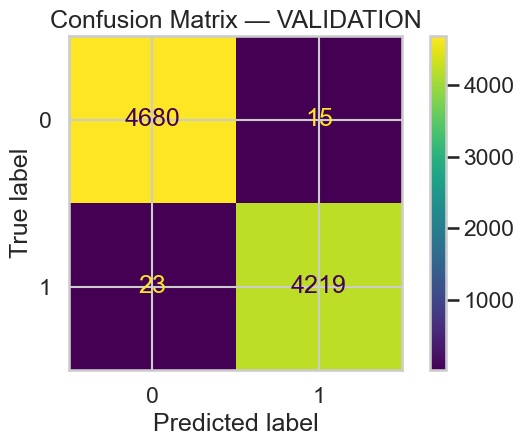


=== TEST metrics ===
              precision    recall  f1-score   support

           0      0.996     0.998     0.997      2348
           1      0.998     0.995     0.997      2121

    accuracy                          0.997      4469
   macro avg      0.997     0.997     0.997      4469
weighted avg      0.997     0.997     0.997      4469

Confusion matrix:
 [[2344    4]
 [  10 2111]]
ROC-AUC: 1.000


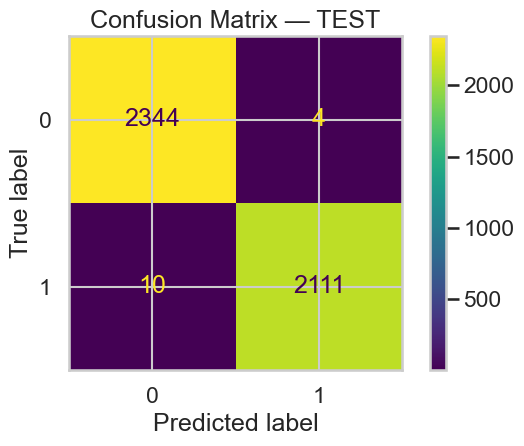


CV accuracy on train+val: mean=0.997 ± 0.001

Top features for TRUE (class 1):
   7.918  reuters
   5.648  said
   3.155  washington reuters
   2.778  on
   2.080  said on
   2.035  reuters the
   1.978  factbox
   1.836  on wednesday
   1.780  washington
   1.714  says
   1.662  in
   1.645  on thursday
   1.637  on tuesday
   1.624  president donald
   1.594  reuters president
   1.518  republican
   1.499  on friday
   1.492  said in
   1.379  on monday
   1.272  wednesday

Top features for FAKE (class 0):
  -4.269  video
  -3.370  via
  -2.731  breaking
  -2.019  read more
  -1.928  this
  -1.890  us
  -1.745  image
  -1.734  read
  -1.726  hillary
  -1.659  featured image
  -1.639  featured
  -1.632  the us
  -1.576  mr
  -1.544  is
  -1.505  image via
  -1.483  that
  -1.473  the
  -1.431  just
  -1.421  gop
  -1.378  gop

Saved model -> svm_text_classifier.joblib
Sanity accuracy with permuted labels (train): 0.4810895488986221


In [20]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import joblib

# -------------------------
# 0) Helpers / preparation
# -------------------------
def split_camel(s: str) -> str:
    return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', s)

def normalize_subject(s: str) -> str:
    if not isinstance(s, str):
        s = "" if s is None else str(s)
    s = s.strip()
    s = split_camel(s)
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s)
    return s.lower()

def prepare(df: pd.DataFrame, label: int) -> pd.DataFrame:
    out = df.copy()
    out["label"] = label
    out["subject_norm"] = out["subject"].astype(str).map(normalize_subject)

    d = pd.to_datetime(out["date"].astype(str).str.strip(), errors="coerce")
    out["year"]  = d.dt.year.astype("Int64").astype(str)     # e.g. "2017" or "<NA>"
    out["month"] = d.dt.to_period("M").astype(str)           # e.g. "2017-12" or "NaT"

    out["title"] = out["title"].fillna("")
    out["text"]  = out["text"].fillna("")
    return out[["title","text","subject_norm","year","month","label"]]

# Prepare and DEDUP FIRST
true_p = prepare(true_df, 1)       # TRUE -> 1
fake_p = prepare(fake_df, 0)       # FAKE -> 0
data   = pd.concat([true_p, fake_p], ignore_index=True)

cols_for_dedup = ["title","text","subject_norm","year","month","label"]
data_ = data.drop_duplicates(subset=cols_for_dedup).reset_index(drop=True)
print("Deduped size:", len(data_))

X = data_.drop(columns=["label"])
y = data_["label"].astype(int)

# ---------------------------------
# 1) Stratified 70/20/10 split ON INDICES
# ---------------------------------
all_idx = np.arange(len(X))

# test = 10%
X_idx_trainval, X_idx_test, y_trainval, y_test = train_test_split(
    all_idx, y, test_size=0.10, stratify=y, random_state=42
)

# val = 20% overall => 2/9 of remaining
X_idx_train, X_idx_val, y_train, y_val = train_test_split(
    X_idx_trainval, y.iloc[X_idx_trainval],
    test_size=2/9, stratify=y.iloc[X_idx_trainval], random_state=42
)

# Prove no overlaps
assert set(X_idx_train).isdisjoint(X_idx_val)
assert set(X_idx_train).isdisjoint(X_idx_test)
assert set(X_idx_val).isdisjoint(X_idx_test)

# Slice AFTER indices are fixed
X_train, X_val, X_test = X.iloc[X_idx_train], X.iloc[X_idx_val], X.iloc[X_idx_test]

print(f"Split sizes -> train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
print(f"Label share (pos=1) -> train: {y_train.mean():.3f}  val: {y_val.mean():.3f}  test: {y_test.mean():.3f}")

# ---------------------------------
# 2) Preprocessing & model
# ---------------------------------
USE_METADATA = False  # set True to include subject/year/month (may cause near-perfect accuracy)

tfidf_title = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.9,
    strip_accents="unicode", lowercase=True
)
tfidf_text = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95,
    strip_accents="unicode", lowercase=True
)

if USE_METADATA:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)  # 'sparse' for broad sklearn compatibility
    preprocess = ColumnTransformer(
        transformers=[
            ("title_tfidf", tfidf_title, "title"),
            ("text_tfidf",  tfidf_text,  "text"),
            ("categoricals", onehot, ["subject_norm","year","month"]),
        ],
        sparse_threshold=1.0
    )
else:
    preprocess = ColumnTransformer(
        transformers=[
            ("title_tfidf", tfidf_title, "title"),
            ("text_tfidf",  tfidf_text,  "text"),
        ],
        sparse_threshold=1.0
    )

svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svm", svm),
])

# ---------------------------------
# 3) Train on train split
# ---------------------------------
clf.fit(X_train, y_train)

# ---------------------------------
# 4) Evaluate on val and test
# ---------------------------------
def evaluate(split_name, X_split, y_split):
    y_pred = clf.predict(X_split)
    print(f"\n=== {split_name} metrics ===")
    print(classification_report(y_split, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_split, y_pred))

    # ROC-AUC using decision_function
    try:
        y_score = clf.decision_function(X_split)
        auc = roc_auc_score(y_split, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception as e:
        print("[info] AUC not available:", e)

    try:
        ConfusionMatrixDisplay.from_predictions(y_split, y_pred)
        plt.title(f"Confusion Matrix — {split_name}")
        plt.tight_layout()
        plt.show()
    except Exception:
        pass

evaluate("VALIDATION", X_val, y_val)
evaluate("TEST",       X_test, y_test)

# ---------------------------------
# 5) Cross-validated accuracy on train+val (optional)
# ---------------------------------
X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_trval, y_trval, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"\nCV accuracy on train+val: mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ---------------------------------
# 6) Inspect top features
# ---------------------------------
def top_linear_svm_features(pipeline: Pipeline, k=20):
    ct: ColumnTransformer = pipeline.named_steps["preprocess"]
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            base = cols if isinstance(cols, (list, tuple)) else [cols]
            fn = trans.get_feature_names_out(base)
            names.extend(fn)
        else:
            base = cols if isinstance(cols, (list, tuple)) else [cols]
            names.extend([f"{name}__{c}" for c in base])

    coef = pipeline.named_steps["svm"].coef_.ravel()
    idx_sorted = np.argsort(coef)
    top_neg = [(names[i], coef[i]) for i in idx_sorted[:k]]            # class 0
    top_pos = [(names[i], coef[i]) for i in idx_sorted[-k:][::-1]]     # class 1
    return top_pos, top_neg

top_true, top_fake = top_linear_svm_features(clf, k=20)
print("\nTop features for TRUE (class 1):")
for f, w in top_true: print(f"{w:>8.3f}  {f}")
print("\nTop features for FAKE (class 0):")
for f, w in top_fake: print(f"{w:>8.3f}  {f}")

# ---------------------------------
# 7) Save model
# ---------------------------------
joblib.dump(clf, "svm_text_classifier.joblib")
print("\nSaved model -> svm_text_classifier.joblib")

# ---------------------------------
# 8) Sanity check with permuted labels (optional)
# ---------------------------------
y_perm = y_train.sample(frac=1.0, random_state=0).values
clf.fit(X_train, y_perm)
print("Sanity accuracy with permuted labels (train):",
      (clf.predict(X_train) == y_train).mean())# =========================
# Leak-proof SVM baseline
# =========================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import joblib

# -------------------------
# 0) Helpers / preparation
# -------------------------
def split_camel(s: str) -> str:
    return re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', s)

def normalize_subject(s: str) -> str:
    if not isinstance(s, str):
        s = "" if s is None else str(s)
    s = s.strip()
    s = split_camel(s)
    s = s.replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+", " ", s)
    return s.lower()

def prepare(df: pd.DataFrame, label: int) -> pd.DataFrame:
    out = df.copy()
    out["label"] = label
    out["subject_norm"] = out["subject"].astype(str).map(normalize_subject)

    d = pd.to_datetime(out["date"].astype(str).str.strip(), errors="coerce")
    out["year"]  = d.dt.year.astype("Int64").astype(str)     # e.g. "2017" or "<NA>"
    out["month"] = d.dt.to_period("M").astype(str)           # e.g. "2017-12" or "NaT"

    out["title"] = out["title"].fillna("")
    out["text"]  = out["text"].fillna("")
    return out[["title","text","subject_norm","year","month","label"]]

# Prepare and DEDUP FIRST
true_p = prepare(true_df, 1)       # TRUE -> 1
fake_p = prepare(fake_df, 0)       # FAKE -> 0
data   = pd.concat([true_p, fake_p], ignore_index=True)

cols_for_dedup = ["title","text","subject_norm","year","month","label"]
data_ = data.drop_duplicates(subset=cols_for_dedup).reset_index(drop=True)
print("Deduped size:", len(data_))

X = data_.drop(columns=["label"])
y = data_["label"].astype(int)

# ---------------------------------
# 1) Stratified 70/20/10 split ON INDICES
# ---------------------------------
all_idx = np.arange(len(X))

# test = 10%
X_idx_trainval, X_idx_test, y_trainval, y_test = train_test_split(
    all_idx, y, test_size=0.10, stratify=y, random_state=42
)

# val = 20% overall => 2/9 of remaining
X_idx_train, X_idx_val, y_train, y_val = train_test_split(
    X_idx_trainval, y.iloc[X_idx_trainval],
    test_size=2/9, stratify=y.iloc[X_idx_trainval], random_state=42
)

# Prove no overlaps
assert set(X_idx_train).isdisjoint(X_idx_val)
assert set(X_idx_train).isdisjoint(X_idx_test)
assert set(X_idx_val).isdisjoint(X_idx_test)

# Slice AFTER indices are fixed
X_train, X_val, X_test = X.iloc[X_idx_train], X.iloc[X_idx_val], X.iloc[X_idx_test]

print(f"Split sizes -> train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")
print(f"Label share (pos=1) -> train: {y_train.mean():.3f}  val: {y_val.mean():.3f}  test: {y_test.mean():.3f}")

# ---------------------------------
# 2) Preprocessing & model
# ---------------------------------
USE_METADATA = False  # set True to include subject/year/month (may cause near-perfect accuracy)

tfidf_title = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.9,
    strip_accents="unicode", lowercase=True
)
tfidf_text = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.95,
    strip_accents="unicode", lowercase=True
)

if USE_METADATA:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=True)  # 'sparse' for broad sklearn compatibility
    preprocess = ColumnTransformer(
        transformers=[
            ("title_tfidf", tfidf_title, "title"),
            ("text_tfidf",  tfidf_text,  "text"),
            ("categoricals", onehot, ["subject_norm","year","month"]),
        ],
        sparse_threshold=1.0
    )
else:
    preprocess = ColumnTransformer(
        transformers=[
            ("title_tfidf", tfidf_title, "title"),
            ("text_tfidf",  tfidf_text,  "text"),
        ],
        sparse_threshold=1.0
    )

svm = LinearSVC(C=1.0, class_weight="balanced", random_state=42)

clf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("svm", svm),
])

# ---------------------------------
# 3) Train on train split
# ---------------------------------
clf.fit(X_train, y_train)

# ---------------------------------
# 4) Evaluate on val and test
# ---------------------------------
def evaluate(split_name, X_split, y_split):
    y_pred = clf.predict(X_split)
    print(f"\n=== {split_name} metrics ===")
    print(classification_report(y_split, y_pred, digits=3))
    print("Confusion matrix:\n", confusion_matrix(y_split, y_pred))

    # ROC-AUC using decision_function
    try:
        y_score = clf.decision_function(X_split)
        auc = roc_auc_score(y_split, y_score)
        print(f"ROC-AUC: {auc:.3f}")
    except Exception as e:
        print("[info] AUC not available:", e)

    try:
        ConfusionMatrixDisplay.from_predictions(y_split, y_pred)
        plt.title(f"Confusion Matrix — {split_name}")
        plt.tight_layout()
        plt.show()
    except Exception:
        pass

evaluate("VALIDATION", X_val, y_val)
evaluate("TEST",       X_test, y_test)

# ---------------------------------
# 5) Cross-validated accuracy on train+val (optional)
# ---------------------------------
X_trval = pd.concat([X_train, X_val], axis=0)
y_trval = pd.concat([y_train, y_val], axis=0)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X_trval, y_trval, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"\nCV accuracy on train+val: mean={cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# ---------------------------------
# 6) Inspect top features
# ---------------------------------
def top_linear_svm_features(pipeline: Pipeline, k=20):
    ct: ColumnTransformer = pipeline.named_steps["preprocess"]
    names = []
    for name, trans, cols in ct.transformers_:
        if name == "remainder":
            continue
        if hasattr(trans, "get_feature_names_out"):
            base = cols if isinstance(cols, (list, tuple)) else [cols]
            fn = trans.get_feature_names_out(base)
            names.extend(fn)
        else:
            base = cols if isinstance(cols, (list, tuple)) else [cols]
            names.extend([f"{name}__{c}" for c in base])

    coef = pipeline.named_steps["svm"].coef_.ravel()
    idx_sorted = np.argsort(coef)
    top_neg = [(names[i], coef[i]) for i in idx_sorted[:k]]            # class 0
    top_pos = [(names[i], coef[i]) for i in idx_sorted[-k:][::-1]]     # class 1
    return top_pos, top_neg

top_true, top_fake = top_linear_svm_features(clf, k=20)
print("\nTop features for TRUE (class 1):")
for f, w in top_true: print(f"{w:>8.3f}  {f}")
print("\nTop features for FAKE (class 0):")
for f, w in top_fake: print(f"{w:>8.3f}  {f}")

# ---------------------------------
# 7) Save model
# ---------------------------------
joblib.dump(clf, "svm_text_classifier.joblib")
print("\nSaved model -> svm_text_classifier.joblib")

# ---------------------------------
# 8) Sanity check with permuted labels (optional)
# ---------------------------------
y_perm = y_train.sample(frac=1.0, random_state=0).values
clf.fit(X_train, y_perm)
print("Sanity accuracy with permuted labels (train):",
      (clf.predict(X_train) == y_train).mean())